In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm

import joblib
import pandas as pd

In [16]:
df = pd.read_csv("../csv/used_cars_1M_2025.csv")
df.head()

,id,country,city,brand,model,year,mileage_km,price_usd,fuel_type,transmission,horsepower,doors,color,condition_score,days_on_market,is_electric
0,1,USA,Adamport,Chevrolet,Silverado,2011.0,185945.0,5903.0,Hybrid,Manual,486.0,3.0,Silver,7.6,285.0,0.0
1,2,France,Mahe,Toyota,Corolla,2017.0,141520.0,9277.0,Plug-in Hybrid,Automatic,473.0,4.0,Brown,4.5,34.0,0.0
2,3,Germany,Hettstedt,BMW,5 Series,2016.0,139091.0,18918.0,Gasoline,Automatic,298.0,4.0,Blue,4.6,27.0,0.0
3,4,Germany,Kulmbach,Honda,CR-V,2007.0,258093.0,5058.0,Gasoline,Automatic,99.0,5.0,White,4.6,362.0,0.0
4,5,USA,Port Cory,Hyundai,Elantra,2017.0,147560.0,16954.0,Hybrid,Automatic,236.0,5.0,Yellow,8.5,359.0,1.0


In [17]:
df.drop("id", axis=1, inplace=True)

In [18]:
print(df.columns)

Index(['country', 'city', 'brand', 'model', 'year', 'mileage_km', 'price_usd',
       'fuel_type', 'transmission', 'horsepower', 'doors', 'color',
       'condition_score', 'days_on_market', 'is_electric'],
      dtype='object')


In [30]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df_sample = df.sample(n=500000, random_state=42)

X = df_sample.drop("price_usd", axis=1)
y = df_sample["price_usd"]


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

num_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_preprocess, num_cols),
        ("cat", cat_preprocess, cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    n_jobs=-1
)

pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", knn)
])

print(pipeline)


Colonnes numériques : ['year', 'mileage_km', 'horsepower', 'doors', 'condition_score', 'days_on_market', 'is_electric']
Colonnes catégorielles : ['country', 'city', 'brand', 'model', 'fuel_type', 'transmission', 'color']
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage_km',
                                                   'horsepower', 'doors',
                                                   'condition_score',
                                                   'days_on_market',
                                                   'is_elect

In [33]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 19054.26935673053
R2: -0.08538425513744019


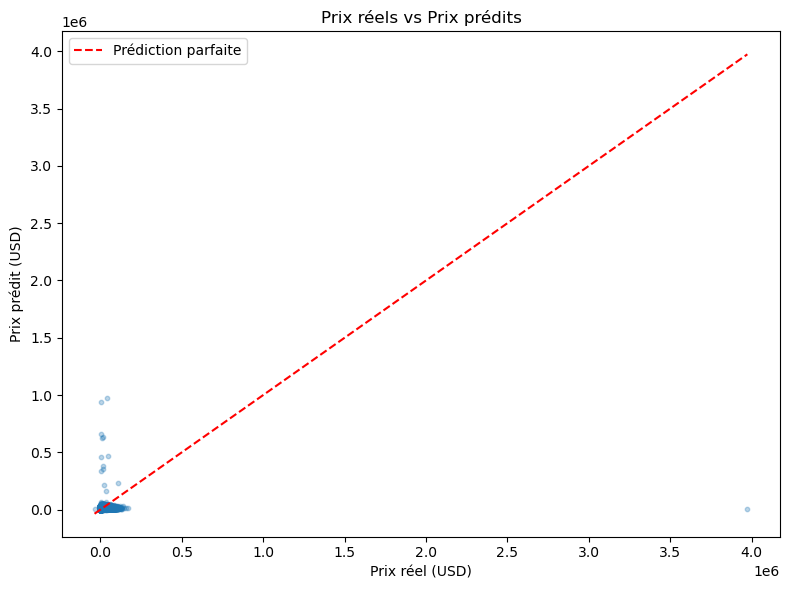

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Prédiction parfaite")
plt.xlabel("Prix réel (USD)")
plt.ylabel("Prix prédit (USD)")
plt.title("Prix réels vs Prix prédits")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
joblib.dump(pipeline, "knn_cars.pkl")

['knn_cars.pkl']